In [2]:
import os
import csv
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import pickle
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm
import geopandas as gpd
from shapely.geometry import Point, Polygon, shape
from pyproj import CRS
import rasterio
import rasterio.sample
from rasterio import mask
from rasterio.features import rasterize
from rasterio.io import MemoryFile
import matplotlib.patches as mpatches
from itertools import product

## Data preparation

### Occurrence data

In [3]:
## -------------------- History occurrence ------------------
preprocessing = False
if preprocessing:
    data_path = 'data/Acer_saccharum.csv'
    df = pd.read_csv(data_path)
    geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
    
    raster_folder = 'data/CHELSA/climate_history'
    raster_files = [f for f in os.listdir(raster_folder) if f.endswith('.tif')]
    
    for raster_file in raster_files:
        raster_path = os.path.join(raster_folder, raster_file)
        raster = rasterio.open(raster_path)
    
        if raster.crs.to_string() != gdf.crs.to_string():
            gdf = gdf.to_crs(raster.crs)
    
        coords = [(x,y) for x, y in zip(gdf.geometry.x, gdf.geometry.y)]
        values = [x[0] for x in raster.sample(coords)]
        variable_name = raster_file.split('_')[1] 
        gdf[variable_name] = values
        df_train = gdf.drop(columns='geometry')
    with open("data/input_train.pkl", 'wb') as f:
        pickle.dump(df_train, f)
else:
    with open("data/input_train.pkl", 'rb') as f:
        df_train = pickle.load(f)

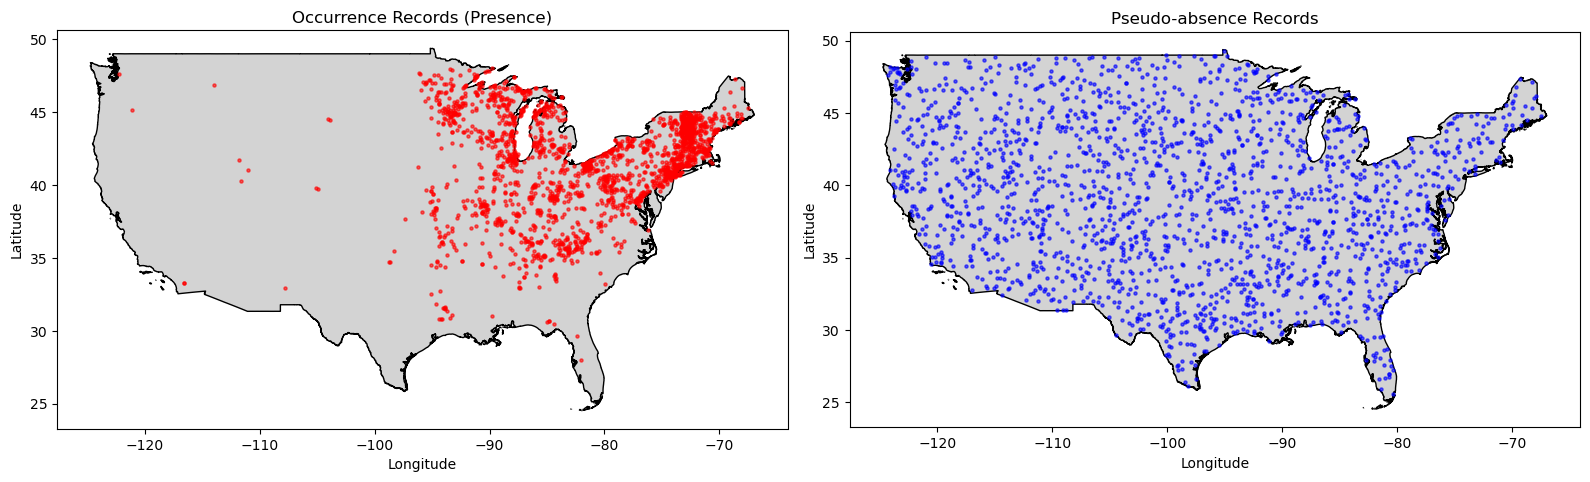

In [44]:
## -------------------- Occurrence display ------------------
conus_map = gpd.read_file("data/geoData/us_boundarydissolve.shp")
df_presence = df_train[df_train['pa'] == 1]
geometry_presence = [Point(xy) for xy in zip(df_presence['lon'], df_presence['lat'])]
gdf_presence = gpd.GeoDataFrame(df_presence, geometry=geometry_presence, crs='EPSG:4326')

df_absence = df_train[df_train['pa'] == 0]
geometry_absence = [Point(xy) for xy in zip(df_absence['lon'], df_absence['lat'])]
gdf_absence = gpd.GeoDataFrame(df_absence, geometry=geometry_absence, crs='EPSG:4326')

fig, axs = plt.subplots(1, 2, figsize=(16, 8)) 

conus_map.plot(ax=axs[0], color='lightgrey', edgecolor='black')
gdf_presence.plot(ax=axs[0], color='red', markersize=5, alpha=0.6)
axs[0].set_title("Occurrence Records (Presence)")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")

conus_map.plot(ax=axs[1], color='lightgrey', edgecolor='black')
gdf_absence.plot(ax=axs[1], color='blue', markersize=5, alpha=0.6)
axs[1].set_title("Pseudo-absence Records")
axs[1].set_xlabel("Longitude")
axs[1].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("occurrence.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

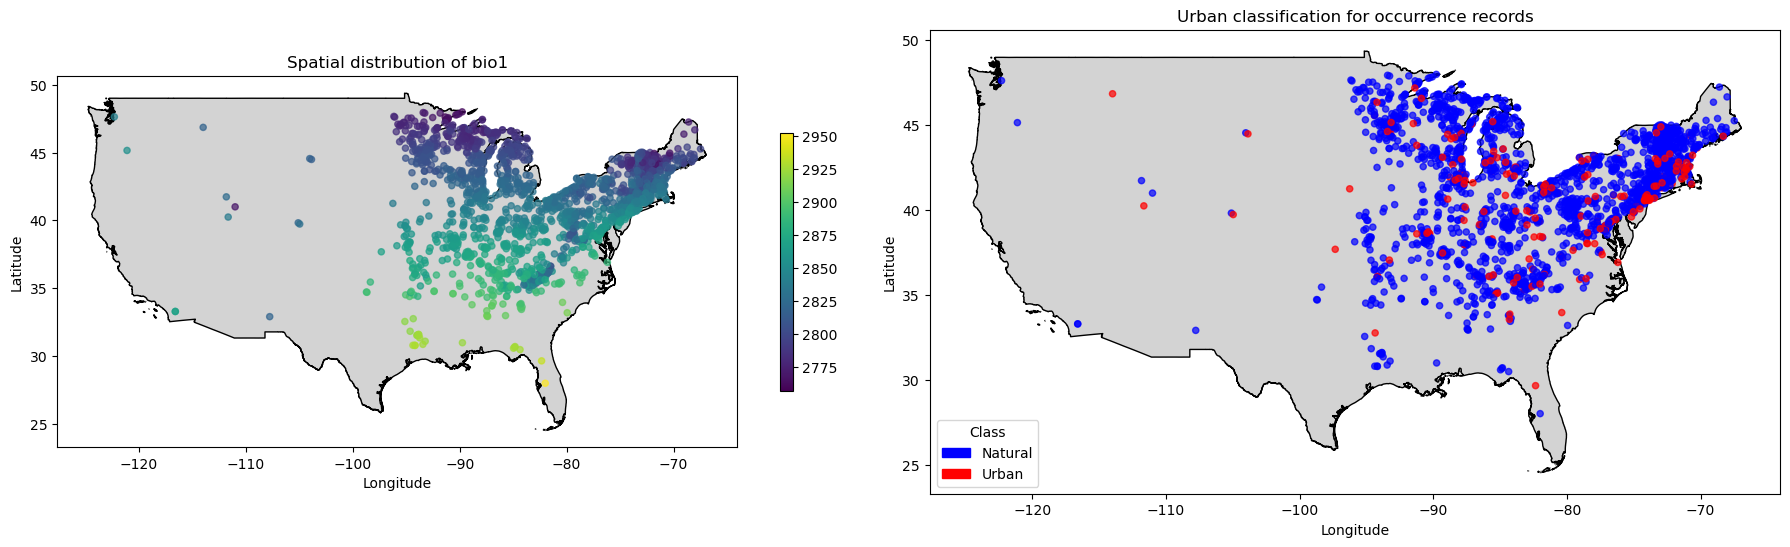

In [45]:
## -------------------- Predictors display ------------------

gdf_presence = gpd.GeoDataFrame(df_presence, geometry=geometry_presence, crs='EPSG:4326')

color_map = {0: 'blue', 1: 'red'}
gdf_presence['color'] = gdf_presence['set'].map(color_map)

fig, axs = plt.subplots(1, 2, figsize=(18, 5.5))

conus_map.plot(ax=axs[0], color='lightgrey', edgecolor='black')
gdf_presence.plot(ax=axs[0],
         column='bio1',
         cmap='viridis',
         markersize=20,
         legend=True,
         alpha=0.7,
         legend_kwds={'shrink': 0.5})
axs[0].set_title("Spatial distribution of bio1")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")

conus_map.plot(ax=axs[1], color='lightgrey', edgecolor='black')
gdf_presence.plot(ax=axs[1],
         color=gdf_presence['color'],
         markersize=20,
         alpha=0.7)

legend_handles = [
    mpatches.Patch(color='blue', label='Natural'),
    mpatches.Patch(color='red', label='Urban')
]
axs[1].legend(handles=legend_handles, title="Class")
axs[1].set_title("Urban classification for occurrence records")
axs[1].set_xlabel("Longitude")
axs[1].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("predictor.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

### Future climate condition

In [71]:
## -------------------- Prediction climate ------------------
preprocessing = False
if preprocessing:
    conus_map = gpd.read_file("data/boundary/us_boundarydissolve.shp")
    urban_map = gpd.read_file("data/boundary/conus_ua.shp")
    conus_map = conus_map.to_crs("EPSG:4326")
    urban_map = urban_map.to_crs("EPSG:4326")
    
    raster_folder = 'data/CHELSA/climate_future'
    raster_files = [f for f in os.listdir(raster_folder) if f.endswith('.tif')]
    df_predict = None
    urban_raster_ready = False
    
    for raster_file in tqdm(raster_files, desc="Processing rasters"):
        raster_path = os.path.join(raster_folder, raster_file)
        variable_name = raster_file.split('_')[1]
    
        with rasterio.open(raster_path) as src:
    
            out_image, out_transform = mask.mask(src, conus_map.geometry, crop=True)
            out_image = out_image[0]
        if not urban_raster_ready:
            urban_raster_full = rasterize(
                [(geom, 1) for geom in urban_map.geometry],
                out_shape=out_image.shape,
                transform=out_transform,
                fill=0,
                dtype='uint8'
            )
            memfile = MemoryFile()
            with memfile.open(
                driver='GTiff',
                height=urban_raster_full.shape[0],
                width=urban_raster_full.shape[1],
                count=1,
                dtype='uint8',
                transform=out_transform,
                crs='EPSG:4326'
            ) as dataset:
                dataset.write(urban_raster_full, 1)
                
                urban_raster_masked, _ = mask.mask(dataset, conus_map.geometry, crop=False)
                urban_raster = urban_raster_masked[0]
        
            urban_raster_ready = True
    
        nrows, ncols = out_image.shape
        rows, cols = np.indices((nrows, ncols))
        xs, ys = rasterio.transform.xy(out_transform, rows, cols)
        xs = np.array(xs).flatten()
        ys = np.array(ys).flatten()
        climate_values = out_image.flatten()
        urban_values = urban_raster.flatten()
    
        valid_mask = (~np.isnan(climate_values)) 
        df = pd.DataFrame({
            'lon': xs[valid_mask],
            'lat': ys[valid_mask],
            variable_name: climate_values[valid_mask],
            'set': urban_values[valid_mask]
        })
    
        if df_predict is None:
            df_predict = df
        else:
            df_predict = pd.merge(df_predict, df[['lon', 'lat', 'set', variable_name]], on=['lon', 'lat', 'set'], how='outer')

    exception_rules = {
        "bio1": [0],
        "bio2": [0],
        "bio3": [3.402823e+38],
        "bio4": [0],
        "bio5": [0],
        "bio6": [0],
        "bio7": [0],
        "bio8": [65535],
        "bio9": [65535],
        "bio10": [65535],
        "bio11": [65535],
        "bio12": [0],
        "bio13": [0],
        "bio14": [0],
        "bio15": [65535],
        "bio16": [65535],
        "bio17": [65535],
        "bio18": [65535],
        "bio19": [65535],
    }
    
    mask = np.full(len(df_predict), False)
    
    for var, bad_values in exception_rules.items():
        if var in df_predict.columns:
            mask = mask | df_predict[var].isin(bad_values)
            
    if "bio3" in df_predict.columns:
        mask = mask | (df_predict["bio3"] > 1e10)
        
    df_predict_clean = df_predict.loc[~mask].reset_index(drop=True)

    tolerance = 1e-7
    df_predict_clean["lon_round"] = (df_predict_clean["lon"] / tolerance).round(0) * tolerance
    df_predict_clean["lat_round"] = (df_predict_clean["lat"] / tolerance).round(0) * tolerance

    cols = df_predict_clean.columns
    data = df_predict_clean.to_numpy()
    lon_lat = data[:, [-1,-2]] 

    lon_lat_str = np.char.add(lon_lat[:,0].astype(str), "_")
    lon_lat_str = np.char.add(lon_lat_str, lon_lat[:,1].astype(str))

    unique_keys, inverse_idx = np.unique(lon_lat_str, return_inverse=True)
    merged_data = np.full((len(unique_keys), data.shape[1]), np.nan)

    for i in tqdm(range(len(data)), desc="Merging rows"):
        idx = inverse_idx[i] 
        for j in range(data.shape[1]):
            if np.isnan(merged_data[idx, j]) and not np.isnan(data[i, j]):
                merged_data[idx, j] = data[i, j]
    df_merged = pd.DataFrame(merged_data, columns=cols)
    df_predict = df_merged.dropna()
    
    with open("data/input_predict.pkl", 'wb') as f:
        pickle.dump(df_predict, f)
else:
    with open("data/input_predict.pkl", 'rb') as f:
        df_predict = pickle.load(f)       

## Model setting

### Integrated functions

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SpData(Dataset):
    """Custom Species Dataset"""
    
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.Y)
    
    def __getitem__(self, idx):
        return{'params': self.X[idx, :], 'label': self.Y[idx]}
    
class MLP(torch.nn.Module):
    """A single layer fully connected neural networks"""
    def __init__(self, input_dim=2, n_hidden_1=64, n_hidden_2=32, n_classes=2, drop_proba=0.5):
        super(MLP, self).__init__()
        
        self.features = torch.nn.Sequential(
            nn.Linear(input_dim, n_hidden_1),
            nn.BatchNorm1d(n_hidden_1),
            nn.PReLU(),
            nn.Dropout(p=drop_proba),
            nn.Linear(n_hidden_1, n_hidden_2),
            nn.BatchNorm1d(n_hidden_2),
            nn.Dropout(p=drop_proba),
            nn.PReLU(),
            nn.Linear(n_hidden_2, n_classes)
        )

    def forward(self, x):
        """
        Returns: 
            logits: Output of the feedfoward neural networs (unnormalized log-probabilities) 
            probs: normalized probabilities. 
        """
        logits = self.features(x)
        probs = F.log_softmax(logits, dim=1)
        return logits, probs

    def predict(self, x):
        logits, probs = self(x)
        return probs.argmax(axis=1).int()
        
    def predict_return_prob(self, x):
        logits, probs = self(x)
        return probs
    
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=5, verbose=False, delta=0,
                 path = 'model/model_state.pth',
                 trace_func=print):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement.
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pt'
            trace_func (function): trace print function.
                            Default: print
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func
    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0
    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.2f} --> {val_loss:.2f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def compute_accuracy(model, data_loader):
    """
    Takes in your model and either the train_dataloader and valid_dataloader above. Calculate the accuracy of
    your model in this dataset.

    NOTE: As explained below it assumes your model has a .predict() method. 
    """
    correct_pred, n_examples = 0, 0
    with torch.no_grad():
        for batch in data_loader: 
            params = batch['params'].to(DEVICE)
            true_counts = batch['label'].to(DEVICE)
            pred_counts = model.predict(params)
            n_examples += true_counts.size(0)
            correct_pred += (pred_counts == true_counts).sum()
        return (correct_pred.float()/n_examples).cpu().item()

def run_training(model, train_loader, valid_loader, optimizer, early_stopping, n_epochs=10):
    val_loss = []
    for epoch in range(n_epochs):
        model.train()
        for batch_idx, batch in enumerate(train_loader):
            params = batch['params'].to(DEVICE)
            true_counts = batch['label'].to(DEVICE)
            # FORWARD AND BACK PROP
            logits, probs = model(params)
            cost = F.cross_entropy(logits, true_counts)
            optimizer.zero_grad()
            cost.backward()

            # UPDATE MODEL PARAMETERS
            optimizer.step()
        # we evaluate our model after each epoch.
        model.eval()
        with torch.no_grad():
            valid_accuracy = compute_accuracy(model, valid_loader)
        val_loss.append(valid_accuracy)
        print('Epoch: %03d/%03d validation accuracy: %.2f' % (epoch+1, n_epochs, valid_accuracy))
        early_stopping((-1)*valid_accuracy, model)
        if early_stopping.early_stop:
            print('Early stopping')
            break
    return val_loss


def compute_roc_auc(test_probs, y_true, resolution=100):
    """
    Compute ROC curve points (FPRs, TPRs) and AUC score.
    """
    thresholds = np.linspace(0, 1, resolution)
    TPRs = []
    FPRs = []
    
    probs_np = test_probs.cpu().detach().numpy()[:, 1]  # Probabilities for class 1
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().detach().numpy()
    
    for threshold in thresholds:
        test_pred = np.int64(probs_np >= threshold)

        TP = np.sum((y_true == 1) & (test_pred == 1))
        FN = np.sum((y_true == 1) & (test_pred == 0))
        FP = np.sum((y_true == 0) & (test_pred == 1))
        TN = np.sum((y_true == 0) & (test_pred == 0))

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        TPRs.append(TPR)
        FPRs.append(FPR)

    roc_auc = auc(FPRs, TPRs)
    
    return FPRs, TPRs, roc_auc


def train_and_evaluate(n_hidden_1, n_hidden_2, drop_proba):
    global best_auc, best_val_loss, best_fpr, best_tpr, best_roc_auc, best_params
    
    path = f'model/model_state_{n_hidden_1}_{n_hidden_2}_{drop_proba}.pth'

    model = MLP(input_dim=X_train.shape[1],
                n_hidden_1=n_hidden_1,
                n_hidden_2=n_hidden_2,
                n_classes=2,
                drop_proba=drop_proba)
    model = model.to(DEVICE)

    early_stopping = EarlyStopping(patience=8, verbose=False,
                                   path=path)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    N_EPOCHS = 100

    # train
    val_loss = run_training(model, train_loader, val_loader, optimizer, early_stopping, n_epochs=N_EPOCHS)
    model.load_state_dict(torch.load(path))

    # evaluate
    model.eval()
    with torch.no_grad():
        test_probs = torch.exp(model.predict_return_prob(X_test.to(DEVICE)))

    FPRs, TPRs, roc_auc = compute_roc_auc(test_probs, Y_test)
    if roc_auc > best_auc:
        best_auc = roc_auc
        best_val_loss = val_loss
        best_fpr = FPRs
        best_tpr = TPRs
        best_roc_auc = roc_auc
        best_params = (n_hidden_1, n_hidden_2, drop_proba)

    return roc_auc

### Training and evaluation

In [72]:
## ------------------------------------------ data for training -------------------------------------
DEVICE = 'cpu'
X = pd.concat([
    df_train.iloc[:, 3],       
    df_train.iloc[:, -19:] 
], axis=1)
Y = df_train.iloc[:, 1]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2024)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1, random_state=2024)

X_train = torch.from_numpy(X_train.to_numpy()).type(torch.float32)
Y_train = torch.from_numpy(Y_train.to_numpy()).type(torch.int64)

X_val = torch.from_numpy(X_val.to_numpy()).type(torch.float32)
Y_val = torch.from_numpy(Y_val.to_numpy()).type(torch.int64)

X_test = torch.from_numpy(X_test.to_numpy()).type(torch.float32)
Y_test = torch.from_numpy(Y_test.to_numpy()).type(torch.int64)

train_dataset = SpData(X_train, Y_train)
val_dataset = SpData(X_val, Y_val)
test_dataset = SpData(X_test, Y_test)
train_loader = DataLoader(dataset = train_dataset,
                          batch_size = 64,
                          shuffle = True,
                          num_workers = 0)
val_loader = DataLoader(dataset = val_dataset,
                          batch_size = 64,
                          shuffle = True,
                          num_workers = 0)
test_loader = DataLoader(dataset = test_dataset,
                          batch_size = 64,
                          shuffle = True,
                          num_workers = 0)

Training with n_hidden_1=16, n_hidden_2=8, drop_proba=0.3
Epoch: 001/100 validation accuracy: 0.75
Epoch: 002/100 validation accuracy: 0.75
Epoch: 003/100 validation accuracy: 0.78
Epoch: 004/100 validation accuracy: 0.80
Epoch: 005/100 validation accuracy: 0.82
Epoch: 006/100 validation accuracy: 0.80
EarlyStopping counter: 1 out of 8
Epoch: 007/100 validation accuracy: 0.77
EarlyStopping counter: 2 out of 8
Epoch: 008/100 validation accuracy: 0.81
EarlyStopping counter: 3 out of 8
Epoch: 009/100 validation accuracy: 0.82
Epoch: 010/100 validation accuracy: 0.82
Epoch: 011/100 validation accuracy: 0.80
EarlyStopping counter: 1 out of 8
Epoch: 012/100 validation accuracy: 0.83
Epoch: 013/100 validation accuracy: 0.82
EarlyStopping counter: 1 out of 8
Epoch: 014/100 validation accuracy: 0.81
EarlyStopping counter: 2 out of 8
Epoch: 015/100 validation accuracy: 0.82
EarlyStopping counter: 3 out of 8
Epoch: 016/100 validation accuracy: 0.81
EarlyStopping counter: 4 out of 8
Epoch: 017/100

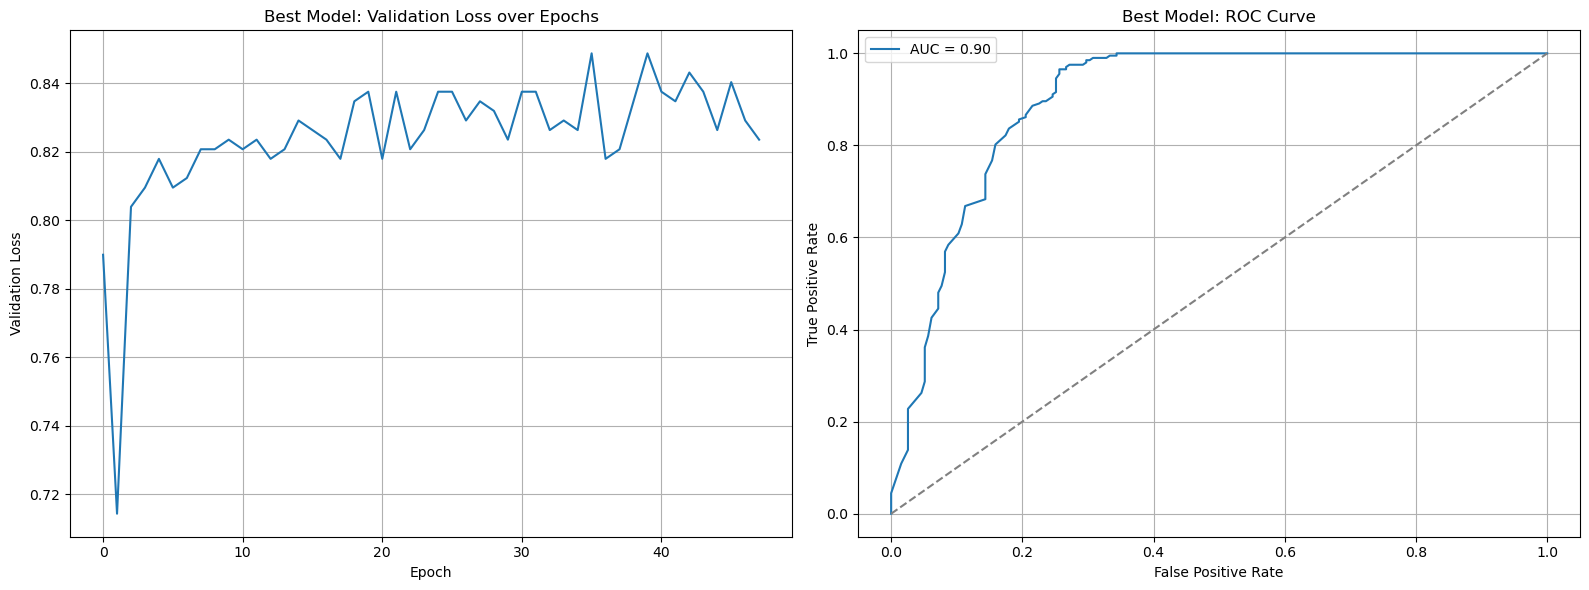

In [30]:
## ------------------------------------------ training and evaluation -------------------------------------
training = False
if training:
    best_auc = 0
    best_val_loss = None
    best_fpr = None
    best_tpr = None
    best_roc_auc = None
    best_params = None

    hidden_1_options = [16, 32, 64]
    hidden_2_options = [8, 16, 32]
    dropout_options = [0.3, 0.5]

    results = []

    # grid search
    for n_hidden_1, n_hidden_2, drop_proba in product(hidden_1_options, hidden_2_options, dropout_options):
        print(f"Training with n_hidden_1={n_hidden_1}, n_hidden_2={n_hidden_2}, drop_proba={drop_proba}")
        auc_value = train_and_evaluate(n_hidden_1, n_hidden_2, drop_proba)
        results.append({
            "n_hidden_1": n_hidden_1,
            "n_hidden_2": n_hidden_2,
            "drop_proba": drop_proba,
            "AUC": auc_value
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="AUC", ascending=False)
    print(results_df)

    print(f"\nBest parameters: n_hidden_1={best_params[0]}, n_hidden_2={best_params[1]}, drop_proba={best_params[2]}")
    print(f"Best AUC = {best_roc_auc:.4f}")

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    axs[0].plot(range(len(best_val_loss)), best_val_loss)
    axs[0].set_title('Best Model: Validation Loss over Epochs')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Validation Loss')
    axs[0].grid(True)

    axs[1].plot(best_fpr, best_tpr, label=f'AUC = {best_roc_auc:.2f}')
    axs[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axs[1].set_title('Best Model: ROC Curve')
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive Rate')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.savefig('best_model_val_loss_and_roc.png')
    plt.show()

### Prediction

In [73]:
## ------------------------------- Prediction ------------------------------
X_columns = X.columns
X_pred = torch.from_numpy(df_predict[X_columns].to_numpy()).type(torch.float32)
best_model_path = f'model/model_state_64_8_0.3.pth'

best_model = MLP(
    input_dim=X_pred.shape[1],
    n_hidden_1=64,
    n_hidden_2=8,
    n_classes=2,
    drop_proba=0.3
)
best_model.load_state_dict(torch.load(best_model_path))
best_model = best_model.to(DEVICE)
best_model.eval()

with torch.no_grad():
    X_pred_tensor = X_pred.to(DEVICE)
    y_pred_class = best_model.predict(X_pred_tensor)
    y_pred_probs = torch.exp(best_model.predict_return_prob(X_pred_tensor))
    
    
df_predict["pred_class"] = y_pred_class.cpu().numpy()
df_predict["pred_prob_0"] = y_pred_probs[:, 0].cpu().numpy()
df_predict["pred_prob_1"] = y_pred_probs[:, 1].cpu().numpy()

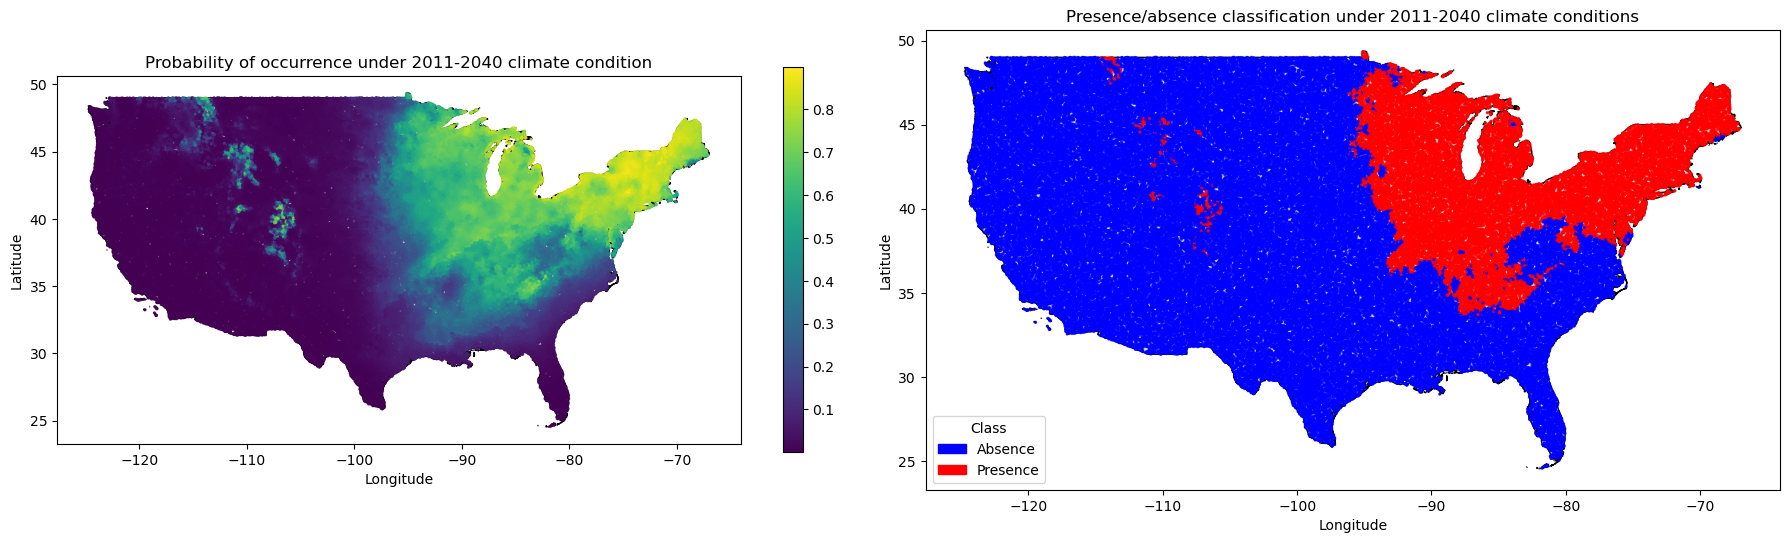

In [75]:
## ------------------------------- Visualization ------------------------------
crs = CRS("EPSG:4326")
geometry = [Point(xy) for xy in zip(df_predict['lon'], df_predict['lat'])]
Position_pred_geo = gpd.GeoDataFrame(df_predict, 
                          crs=crs,
                          geometry=geometry)
Position_pred_sample = Position_pred_geo.sample(n=100000, random_state=42) # no need to plot all points
color_map = {0: 'blue', 1: 'red'}
Position_pred_sample['color'] = Position_pred_sample['pred_class'].map(color_map)

fig, axs = plt.subplots(1, 2, figsize=(18, 8))

conus_map.plot(ax=axs[0], color='lightgrey', edgecolor='black')
Position_pred_sample.plot(ax=axs[0],
         column='pred_prob_1',
         cmap='viridis',
         markersize=2,
         legend=True,
         alpha=0.7,
         legend_kwds={'shrink': 0.5})
axs[0].set_title("Probability of occurrence under 2011-2040 climate condition")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")

conus_map.plot(ax=axs[1], color='lightgrey', edgecolor='black')
Position_pred_sample.plot(ax=axs[1],
         color=Position_pred_sample['color'],
         markersize=2,
         alpha=0.7)

legend_handles = [
    mpatches.Patch(color='blue', label='Absence'),
    mpatches.Patch(color='red', label='Presence')
]
axs[1].legend(handles=legend_handles, title="Class")
axs[1].set_title("Presence/absence classification under 2011-2040 climate conditions")
axs[1].set_xlabel("Longitude")
axs[1].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("prediction.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()